In [1]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [2]:
for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if files:
        print("  Files:", files[:5])

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/andradaolteanu
/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data
  Files: ['features_3_sec.csv', 'features_30_sec.csv']
/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/images_original
/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/images_original/disco
  Files: ['disco00005.png', 'disco00057.png', 'disco00020.png', 'disco00072.png', 'disco00040.png']
/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/images_original/metal
  Files: ['metal00022.png', 'metal00042.png', 'metal00033.png', 'metal00064.png', 'metal00039.png']
/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/images_original/reggae
  Files: ['reggae00022.png', 'reggae00045.png', 'reggae00061.png', 'reggae00034.png', 'r

In [3]:
import pandas as pd

path = "/kaggle/input/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/Data/features_3_sec.csv"

df = pd.read_csv(path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Shape: (9990, 60)

Columns:
['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var', 'label']


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [4]:
print(df['label'].value_counts())

label
blues        1000
jazz         1000
pop          1000
reggae       1000
metal        1000
disco         999
classical     998
hiphop        998
rock          998
country       997
Name: count, dtype: int64


In [5]:
# Extract original song ID
df['song_id'] = df['filename'].str.replace(
    r'\.\d+\.wav$', '', regex=True
)

print("Total 3-sec segments:", len(df))
print("Unique original songs:", df['song_id'].nunique())

display(df[['filename', 'song_id', 'label']].head(12))

Total 3-sec segments: 9990
Unique original songs: 1000


,filename,song_id,label
0,blues.00000.0.wav,blues.00000,blues
1,blues.00000.1.wav,blues.00000,blues
2,blues.00000.2.wav,blues.00000,blues
3,blues.00000.3.wav,blues.00000,blues
4,blues.00000.4.wav,blues.00000,blues
5,blues.00000.5.wav,blues.00000,blues
6,blues.00000.6.wav,blues.00000,blues
7,blues.00000.7.wav,blues.00000,blues
8,blues.00000.8.wav,blues.00000,blues
9,blues.00000.9.wav,blues.00000,blues


In [6]:
#Split songs into train / validation / test
from sklearn.model_selection import train_test_split

# Get one row per original song
songs = df[['song_id', 'label']].drop_duplicates()

# 70% train, 30% temporary
train_songs, temp_songs = train_test_split(
    songs,
    test_size=0.30,
    random_state=42,
    stratify=songs['label']
)

# Split remaining 30% into 15% validation and 15% test
val_songs, test_songs = train_test_split(
    temp_songs,
    test_size=0.50,
    random_state=42,
    stratify=temp_songs['label']
)

print("Training songs:", len(train_songs))
print("Validation songs:", len(val_songs))
print("Testing songs:", len(test_songs))

Training songs: 700
Validation songs: 150
Testing songs: 150


In [7]:
#Create the actual train/validation/test data

In [8]:
# Create datasets using the song-level split

train_df = df[df['song_id'].isin(train_songs['song_id'])].copy()
val_df   = df[df['song_id'].isin(val_songs['song_id'])].copy()
test_df  = df[df['song_id'].isin(test_songs['song_id'])].copy()

print("Train segments:", len(train_df))
print("Validation segments:", len(val_df))
print("Test segments:", len(test_df))

Train segments: 6990
Validation segments: 1500
Test segments: 1500


In [9]:
feature_cols = [
    col for col in df.columns
    if col not in ['filename', 'song_id', 'label', 'length']
]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 57
['chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo', 'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean', 'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean', 'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var', 'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean', 'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var', 'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean', 'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var']


In [10]:
#scale the features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[feature_cols])
X_val = scaler.transform(val_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (6990, 57)
X_val shape: (1500, 57)
X_test shape: (1500, 57)


In [11]:
#Convert the genre names into numbers
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df['label'])
y_val = label_encoder.transform(val_df['label'])
y_test = label_encoder.transform(test_df['label'])

print("Classes:", label_encoder.classes_)
print("First 10 encoded labels:", y_train[:10])

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
First 10 encoded labels: [0 0 0 0 0 0 0 0 0 0]


In [12]:
# Reshape data for 1D CNN

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("X_train CNN shape:", X_train_cnn.shape)
print("X_val CNN shape:", X_val_cnn.shape)
print("X_test CNN shape:", X_test_cnn.shape)

X_train CNN shape: (6990, 57, 1)
X_val CNN shape: (1500, 57, 1)
X_test CNN shape: (1500, 57, 1)


In [ ]:
#1D CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(57, 1)),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

model.summary()

In [14]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4416 - loss: 1.5562 - val_accuracy: 0.6000 - val_loss: 1.1855
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6183 - loss: 1.1015 - val_accuracy: 0.6467 - val_loss: 1.0409
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6937 - loss: 0.8783 - val_accuracy: 0.6707 - val_loss: 0.9824
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7352 - loss: 0.7624 - val_accuracy: 0.6660 - val_loss: 0.9585
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7704 - loss: 0.6617 - val_accuracy: 0.6793 - val_loss: 0.9458
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8006 - loss: 0.5787 - val_accuracy: 0.6967 - val_loss: 0.9767
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8268 - loss: 0.5025 - val_accuracy: 0.6860 - val_loss: 1.0156
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8435 - loss: 0.4409 - val_accuracy: 0.

In [16]:
test_loss, test_accuracy = model.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6580 - loss: 1.2180
Test Loss: 1.2179877758026123
Test Accuracy: 0.6579999923706055


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Get predictions
y_pred_prob = model.predict(X_test_cnn)
y_pred = y_pred_prob.argmax(axis=1)

# Calculate metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Precision: 0.6633878987866381
Recall: 0.658
F1-Score: 0.6548878156745257


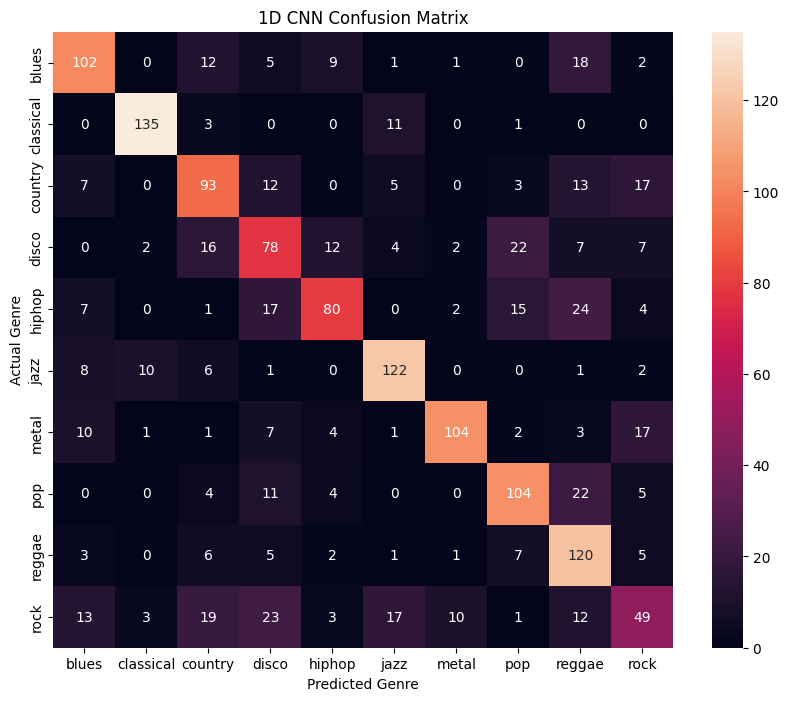

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title("1D CNN Confusion Matrix")
plt.show()

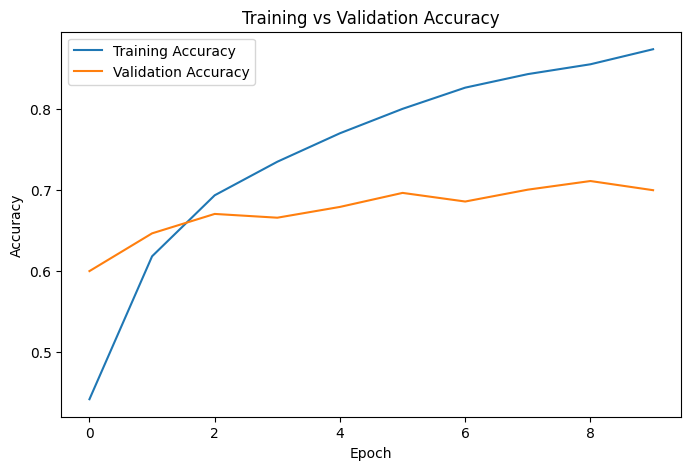

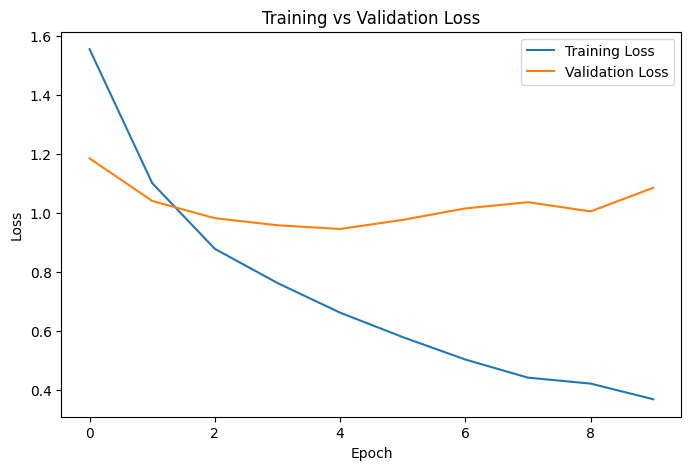

In [19]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization,
    Flatten, Dense, Dropout
)

improved_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(57, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

improved_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 55, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 55, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 25, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        98,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,746 (487.29 KB)

 Trainable params: 124,362 (485.79 KB)

 Non-trainable params: 384 (1.50 KB)

In [21]:
from tensorflow.keras.optimizers import Adam

improved_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Improved model compiled successfully!")

Improved model compiled successfully!


In [22]:
from tensorflow.keras.callbacks import EarlyStopping

improved_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

improved_history = improved_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[improved_early_stop],
    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3474 - loss: 1.9569 - val_accuracy: 0.4193 - val_loss: 1.7519
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.4871 - loss: 1.4593 - val_accuracy: 0.5773 - val_loss: 1.1354
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5475 - loss: 1.2980 - val_accuracy: 0.6240 - val_loss: 1.0527
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5967 - loss: 1.1503 - val_accuracy: 0.6433 - val_loss: 1.0203
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6258 - loss: 1.0807 - val_accuracy: 0.6567 - val_loss: 0.9772
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6391 - loss: 1.0090 - val_accuracy: 0.6767 - val_loss: 0.9806
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6619 - loss: 0.9655 - val_accuracy: 0.6620 - val_loss: 0.9900
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6777 - loss: 0.9077 - val_accu

In [23]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(
    X_test_cnn,
    y_test,
    verbose=1
)

print("Improved Test Loss:", improved_test_loss)
print("Improved Test Accuracy:", improved_test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6593 - loss: 1.1733
Improved Test Loss: 1.1733253002166748
Improved Test Accuracy: 0.659333348274231


In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Predictions from improved model
improved_pred_prob = improved_model.predict(X_test_cnn)
improved_y_pred = improved_pred_prob.argmax(axis=1)

# Metrics
improved_precision = precision_score(
    y_test, improved_y_pred, average='weighted'
)

improved_recall = recall_score(
    y_test, improved_y_pred, average='weighted'
)

improved_f1 = f1_score(
    y_test, improved_y_pred, average='weighted'
)

print("Improved Precision:", improved_precision)
print("Improved Recall:", improved_recall)
print("Improved F1-Score:", improved_f1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Improved Precision: 0.6599826987129156
Improved Recall: 0.6593333333333333
Improved F1-Score: 0.6566804408894522


In [25]:
import librosa
import numpy as np

print("Librosa version:", librosa.__version__)

Librosa version: 0.11.0


In [26]:
import librosa
import numpy as np

audio_path = (
    "/kaggle/input/datasets/andradaolteanu/"
    "gtzan-dataset-music-genre-classification/"
    "Data/genres_original/blues/blues.00000.wav"
)

y, sr = librosa.load(audio_path, sr=22050, duration=3)

mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=40
)

print("Audio shape:", y.shape)
print("Sampling rate:", sr)
print("MFCC shape:", mfcc.shape)

Audio shape: (66150,)
Sampling rate: 22050
MFCC shape: (40, 130)


In [27]:
import pandas as pd

csv_path = (
    "/kaggle/input/datasets/andradaolteanu/"
    "gtzan-dataset-music-genre-classification/"
    "Data/features_3_sec.csv"
)

df = pd.read_csv(csv_path)

# Create original song ID
df['song_id'] = df['filename'].str.replace(
    r'\.\d+\.wav$', '', regex=True
)

print("Dataset loaded:", df.shape)
print("Unique songs:", df['song_id'].nunique())

Dataset loaded: (9990, 61)
Unique songs: 1000


In [ ]:
#Load only the required 3-second piece → calculate MFCC

In [29]:
import os
import re
import numpy as np
import librosa

audio_base = (
    "/kaggle/input/datasets/andradaolteanu/"
    "gtzan-dataset-music-genre-classification/"
    "Data/genres_original"
)

N_MFCC = 40
SR = 22050
N_FFT = 2048
HOP_LENGTH = 512
SEGMENT_DURATION = 3

X_mfcc = []
y_mfcc = []
song_ids_mfcc = []
skipped_files = []

for i, (song_id, group) in enumerate(df.groupby('song_id')):

    label = group['label'].iloc[0]
    audio_file = os.path.join(
        audio_base,
        label,
        song_id + ".wav"
    )

    try:

        for _, row in group.iterrows():

            segment_no = int(
                re.search(
                    r'\.(\d+)\.wav$',
                    row['filename']
                ).group(1)
            )

            # Load ONLY this 3-second segment
            audio, sr = librosa.load(
                audio_file,
                sr=SR,
                offset=segment_no * SEGMENT_DURATION,
                duration=SEGMENT_DURATION
            )

            # Skip unusually short segments
            if len(audio) < SEGMENT_DURATION * SR * 0.9:
                continue

            mfcc = librosa.feature.mfcc(
                y=audio,
                sr=SR,
                n_mfcc=N_MFCC,
                n_fft=N_FFT,
                hop_length=HOP_LENGTH
            )

            X_mfcc.append(mfcc.T)
            y_mfcc.append(label)
            song_ids_mfcc.append(song_id)

    except Exception as e:
        skipped_files.append(song_id)
        print("Skipped:", song_id)

    # Progress indicator
    if (i + 1) % 50 == 0:
        print(
            f"Processed {i + 1}/1000 songs | "
            f"Segments: {len(X_mfcc)}"
        )

X_mfcc = np.array(X_mfcc, dtype=np.float32)
y_mfcc = np.array(y_mfcc)
song_ids_mfcc = np.array(song_ids_mfcc)

print("\n========== RESULTS ==========")
print("MFCC dataset shape:", X_mfcc.shape)
print("Labels shape:", y_mfcc.shape)
print("Unique songs processed:", len(np.unique(song_ids_mfcc)))
print("Songs skipped:", len(skipped_files))

Processed 50/1000 songs | Segments: 500
Processed 100/1000 songs | Segments: 1000
Processed 150/1000 songs | Segments: 1499
Processed 200/1000 songs | Segments: 1998
Processed 250/1000 songs | Segments: 2495
Processed 300/1000 songs | Segments: 2995
Processed 350/1000 songs | Segments: 3494
Processed 400/1000 songs | Segments: 3994
Processed 450/1000 songs | Segments: 4492
Processed 500/1000 songs | Segments: 4992
Processed 550/1000 songs | Segments: 5492


/tmp/ipykernel_58/238782867.py:44: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipped: jazz.00054
Processed 600/1000 songs | Segments: 5982
Processed 650/1000 songs | Segments: 6482
Processed 700/1000 songs | Segments: 6982
Processed 750/1000 songs | Segments: 7482
Processed 800/1000 songs | Segments: 7982
Processed 850/1000 songs | Segments: 8482
Processed 900/1000 songs | Segments: 8982
Processed 950/1000 songs | Segments: 9480
Processed 1000/1000 songs | Segments: 9980

========== RESULTS ==========
MFCC dataset shape: (9980, 130, 40)
Labels shape: (9980,)
Unique songs processed: 999
Songs skipped: 1


In [31]:
#split the MFCC data
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# Create sets of song IDs
train_ids = set(train_songs['song_id'])
val_ids = set(val_songs['song_id'])
test_ids = set(test_songs['song_id'])

# Create masks
train_mask = np.array([s in train_ids for s in song_ids_mfcc])
val_mask = np.array([s in val_ids for s in song_ids_mfcc])
test_mask = np.array([s in test_ids for s in song_ids_mfcc])

# Split MFCC data
X_mfcc_train = X_mfcc[train_mask]
X_mfcc_val = X_mfcc[val_mask]
X_mfcc_test = X_mfcc[test_mask]

y_mfcc_train = y_mfcc[train_mask]
y_mfcc_val = y_mfcc[val_mask]
y_mfcc_test = y_mfcc[test_mask]

print("Before scaling:")
print("Train:", X_mfcc_train.shape)
print("Validation:", X_mfcc_val.shape)
print("Test:", X_mfcc_test.shape)

# Encode labels
mfcc_encoder = LabelEncoder()

y_mfcc_train = mfcc_encoder.fit_transform(y_mfcc_train)
y_mfcc_val = mfcc_encoder.transform(y_mfcc_val)
y_mfcc_test = mfcc_encoder.transform(y_mfcc_test)

# Scale MFCC features
# Reshape so StandardScaler works across the 40 MFCC features
n_train, time_steps, n_features = X_mfcc_train.shape

scaler_mfcc = StandardScaler()

X_train_2d = X_mfcc_train.reshape(-1, n_features)
X_val_2d = X_mfcc_val.reshape(-1, n_features)
X_test_2d = X_mfcc_test.reshape(-1, n_features)

X_train_2d = scaler_mfcc.fit_transform(X_train_2d)
X_val_2d = scaler_mfcc.transform(X_val_2d)
X_test_2d = scaler_mfcc.transform(X_test_2d)

# Convert back to CNN shape
X_mfcc_train = X_train_2d.reshape(
    X_mfcc_train.shape
)

X_mfcc_val = X_val_2d.reshape(
    X_mfcc_val.shape
)

X_mfcc_test = X_test_2d.reshape(
    X_mfcc_test.shape
)

print("\nAfter scaling:")
print("X_mfcc_train:", X_mfcc_train.shape)
print("X_mfcc_val:", X_mfcc_val.shape)
print("X_mfcc_test:", X_mfcc_test.shape)

print("\nClasses:", mfcc_encoder.classes_)

Before scaling:
Train: (6980, 130, 40)
Validation: (1500, 130, 40)
Test: (1500, 130, 40)

After scaling:
X_mfcc_train: (6980, 130, 40)
X_mfcc_val: (1500, 130, 40)
X_mfcc_test: (1500, 130, 40)

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [32]:
#Build the MFCC-based 1D CNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

mfcc_cnn = Sequential([
    
    Conv1D(
        64,
        kernel_size=5,
        activation='relu',
        input_shape=(130, 40)
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(
        128,
        kernel_size=5,
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    Conv1D(
        256,
        kernel_size=3,
        activation='relu'
    ),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    GlobalAveragePooling1D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

mfcc_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 126, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 126, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 59, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 59, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 29, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 29, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 27, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 27, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 13, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,490 (736.29 KB)

 Trainable params: 187,594 (732.79 KB)

 Non-trainable params: 896 (3.50 KB)

In [34]:
from tensorflow.keras.optimizers import Adam

mfcc_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("MFCC CNN compiled successfully!")

MFCC CNN compiled successfully!


In [35]:
from tensorflow.keras.callbacks import EarlyStopping

mfcc_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

mfcc_history = mfcc_cnn.fit(
    X_mfcc_train,
    y_mfcc_train,
    validation_data=(X_mfcc_val, y_mfcc_val),
    epochs=30,
    batch_size=32,
    callbacks=[mfcc_early_stop],
    verbose=1
)

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.4678 - loss: 1.5380 - val_accuracy: 0.4893 - val_loss: 1.3721
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.6142 - loss: 1.1453 - val_accuracy: 0.6007 - val_loss: 1.1477
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.6679 - loss: 0.9823 - val_accuracy: 0.6307 - val_loss: 1.0747
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7069 - loss: 0.8586 - val_accuracy: 0.6293 - val_loss: 1.1257
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7491 - loss: 0.7556 - val_accuracy: 0.6420 - val_loss: 1.0849
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.7546 - loss: 0.7053 - val_accuracy: 0.6753 - val_loss: 0.9774
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7834 - loss: 0.6366 - val_accuracy: 0.6720 - val_loss: 0.9947
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.7977 - loss: 0.5873 - val_acc

In [36]:
mfcc_test_loss, mfcc_test_accuracy = mfcc_cnn.evaluate(
    X_mfcc_test,
    y_mfcc_test,
    verbose=1
)

print("MFCC CNN Test Loss:", mfcc_test_loss)
print("MFCC CNN Test Accuracy:", mfcc_test_accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6527 - loss: 1.1840
MFCC CNN Test Loss: 1.1839818954467773
MFCC CNN Test Accuracy: 0.6526666879653931


In [37]:
from sklearn.metrics import precision_score, recall_score, f1_score

mfcc_pred_prob = mfcc_cnn.predict(X_mfcc_test)
mfcc_y_pred = mfcc_pred_prob.argmax(axis=1)

mfcc_precision = precision_score(
    y_mfcc_test,
    mfcc_y_pred,
    average='weighted'
)

mfcc_recall = recall_score(
    y_mfcc_test,
    mfcc_y_pred,
    average='weighted'
)

mfcc_f1 = f1_score(
    y_mfcc_test,
    mfcc_y_pred,
    average='weighted'
)

print("MFCC Precision:", mfcc_precision)
print("MFCC Recall:", mfcc_recall)
print("MFCC F1-Score:", mfcc_f1)

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
MFCC Precision: 0.6827154004621508
MFCC Recall: 0.6526666666666666
MFCC F1-Score: 0.65514723794905
